In [15]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sleap
import numpy as np
import datetime
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import ConnectionPatch
from pathlib import Path
from itertools import combinations
from scipy.stats import wilcoxon
from scipy.stats import friedmanchisquare

In [16]:
import sleap_roots_training

from sleap_roots_training.evaluate import (main, 
                                           predictions_viz_from_sleap_files, 
                                           fetch_sweep_metrics, 
                                           get_sweep_ids_for_group_from_runs, 
                                           visualize_predictions_from_artifacts,
)


In [17]:
# Constants for W&B initialization
ENTITY_NAME = "eberrigan-salk-institute-for-biological-studies"
PROJECT_NAME = "sleap-roots"
REGISTRY = "sleap-roots-models"
JOB_TYPE = "evaluation"
EXPERIMENT_NAME = "20250625_cyl_arabidopsis_primary_receptive_field"

# Constants for artifact creation
DESCRIPTION = "7-11 DAG arabidopsis primary root in cylinders with 6 nodes varying max stride [8, 16, 32, 64] sweep"
TAGS = ["cyl", "arabidopsis", "7-11DAG", "primary", "6nodes", "arabidopsis7-11DAG", "2026-06-25", "max_stride_sweep"]
COLLECTION_NAME = EXPERIMENT_NAME
CSV_PATH = "//multilab-na.ad.salk.edu/hpi_dev/users/eberrigan/SLEAP/20250625_cyl_arabidopsis_primary_receptive_field/train_test_splits.csv"
ARTIFACT_NAME = "cyl_arabidopsis_primary_receptive_field_max_stride_sweep_n6_evaluation"

# Model and group configuration
# https://wandb.ai/eberrigan-salk-institute-for-biological-studies/sleap-roots/groups
MODEL_GROUP = "20250625_cyl_arabidopsis_primary_receptive_field" # This is the group name for the sweep
TARGET_METRICS = ["dist_p50", "dist_p90", "dist_p95", "dist_p99", "dist_avg", "dist_std", "vis_prec", "vis_recall", "oks_map", "oks_mar"]

In [18]:
sleap_roots_training.reset_config()

Configuration updated successfully at c:\repos\sleap-roots-training\sleap_roots_training\config.yaml.
Configuration has been reset to default values.


In [19]:
sleap_roots_training.update_config(entity_name=ENTITY_NAME, project_name=PROJECT_NAME, registry=REGISTRY, experiment_name=EXPERIMENT_NAME)

Configuration updated successfully at c:\repos\sleap-roots-training\sleap_roots_training\config.yaml.
CONFIG updated to {'project_name': 'sleap-roots', 'entity_name': 'eberrigan-salk-institute-for-biological-studies', 'experiment_name': '20250625_cyl_arabidopsis_primary_receptive_field', 'registry': 'sleap-roots-models', 'collection_name': None, 'job_type': None}.


In [20]:
# Make directory for experiment
Path(EXPERIMENT_NAME).mkdir(exist_ok=True, parents=True)

In [21]:
datetime_str = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [22]:
# sweep_ids = get_sweep_ids_for_group_from_runs(group_name=MODEL_GROUP)
sweep_ids = get_sweep_ids_for_group_from_runs(
    group_name=MODEL_GROUP,
    earliest_time="2025-06-26T15:30:27Z"
)

INFO:root:Found 25 runs in group '20250625_cyl_arabidopsis_primary_receptive_field' with filters: {'group': '20250625_cyl_arabidopsis_primary_receptive_field', 'createdAt': {'$gte': '2025-06-26T15:30:27Z'}}
INFO:root:Found 6 unique sweep IDs: ['1ltq54xm', '4toalned', '5vywolb1', 'dagu7lx7', 'dpg1hwjg', 'pqxiu4ua']


In [23]:
sweep_df = fetch_sweep_metrics(
    sweep_ids=sweep_ids,
    target_metrics=TARGET_METRICS,
    include_config=True,
)

In [24]:
sweep_df

,run_id,name,group,sweep_id,dist_p50,dist_p90,dist_p95,dist_p99,dist_avg,dist_std,...,config/name,config/model,config/outputs,config/version,config/filename,config/config_path,config/description,config/optimization,config/sleap_version,config/model.backbone.unet.max_stride
0,j5dfx4mi,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,1ltq54xm,NaN,NaN,NaN,NaN,NaN,NaN,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,1,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,64
1,tufh28xl,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,1ltq54xm,0.686944,6.928166,10.830005,18.774118,2.343083,3.725731,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,1,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,32
2,kuj9yu6a,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,1ltq54xm,0.855412,7.339192,14.798622,22.531768,3.018990,5.170160,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,1,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,16
3,zhfksl8x,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,1ltq54xm,0.396487,2.089329,2.406267,2.659817,0.921288,1.055359,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,1,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,8
4,mwxugnt4,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,4toalned,NaN,NaN,NaN,NaN,NaN,NaN,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,4,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,64
5,um1yn9kk,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,4toalned,0.938614,6.123696,9.011044,12.299244,2.164863,2.885956,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,4,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,32
6,wssshnqi,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,4toalned,0.721332,8.595725,11.733068,16.107305,2.358447,3.827317,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,4,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,16
7,onn9jyxf,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,4toalned,NaN,NaN,NaN,NaN,NaN,NaN,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.1:9...,4,\\multilab-na.ad.salk.edu\hpi_dev\users\eberri...,//multilab-na.ad.salk.edu/hpi_dev/users/eberri...,,"{'epochs': 200, 'prefetch': True, 'optimizer':...",1.4.1a2,8
8,26ryyfu2,20250625_cyl_arabidopsis_primary_receptive_fie...,20250625_cyl_arabidopsis_primary_receptive_field,5vywolb1,NaN,NaN,NaN,NaN,NaN,NaN,...,,"{'heads': {'centroid': None, 'multi_instance':...",{'zmq': {'publish_address': 'tcp://127.0.0.

In [25]:
sweep_csv_path = Path(EXPERIMENT_NAME) / f"sweep_metrics_{datetime_str}.csv"
sweep_df.to_csv(sweep_csv_path, index=False)
print(f"Sweep metrics saved to {sweep_csv_path}")

Sweep metrics saved to 20250625_cyl_arabidopsis_primary_receptive_field\sweep_metrics_2025-07-01_09-00-20.csv


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


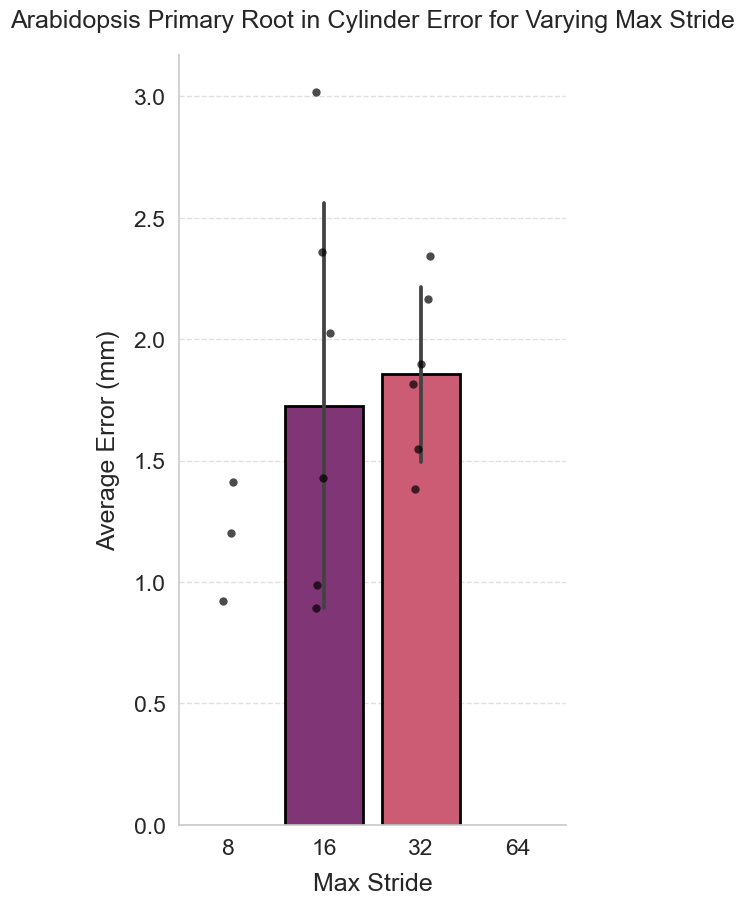

Plot saved to 20250625_cyl_arabidopsis_primary_receptive_field\2025-07-01_09-00-20_max_stride_sweep_eval.png


In [26]:
# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}


plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# ========== LOAD LABEL COUNTS ==========
label_csv_path = CSV_PATH
df_labels = pd.read_csv(label_csv_path)

# Sum train + val + test labels per crop using version 0 since all versions have the same ratios of train/val/test
df_labels_v0 = df_labels[df_labels["version"] == 0]
total_labeled_per_crop = df_labels_v0["labeled_frames"].sum()

data = sweep_df.copy()

# ========== PLOTTING ==========
plt.figure(figsize=(5, 10))

# Barplot (median dist_avg)
ax = sns.barplot(
    data=sweep_df, x="config/model.backbone.unet.max_stride", y="dist_avg",
    estimator=np.median, errorbar="sd",
    palette="magma", edgecolor="black", linewidth=2
)

# Overlay raw points
sns.stripplot(
    data=sweep_df, x="config/model.backbone.unet.max_stride", y="dist_avg",
    color="black", size=6, alpha=0.7, jitter=True
)

# Title and axis labels
plt.title("Arabidopsis Primary Root in Cylinder Error for Varying Max Stride", pad=20)
plt.xlabel("Max Stride", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

# Readability adjustments
# plt.xticks(rotation=45, ha="right")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)


# Save
plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval.png"
plt.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Plot saved to {plot_file_path}")

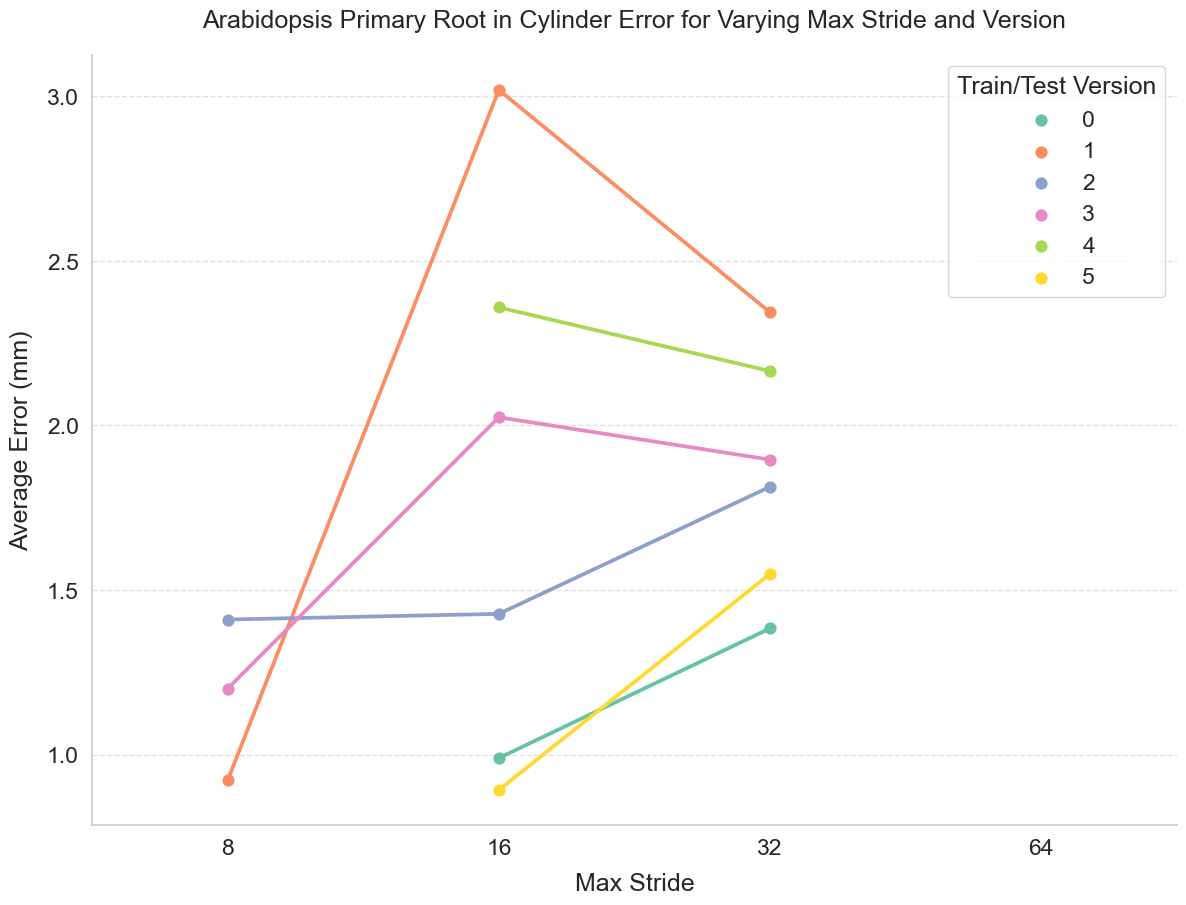

Plot saved to 20250625_cyl_arabidopsis_primary_receptive_field\2025-07-01_09-00-20_max_stride_sweep_eval_version.png


In [27]:
# ========== SETTINGS ==========
font_settings = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 26
}


plt.rcParams.update(font_settings)
sns.set_theme(style="whitegrid", font_scale=1.5)

# ========== LOAD LABEL COUNTS ==========
label_csv_path = CSV_PATH
df_labels = pd.read_csv(label_csv_path)

# Sum train + val + test labels per crop using version 0 since all versions have the same ratios of train/val/test
df_labels_v0 = df_labels[df_labels["version"] == 0]
total_labeled_per_crop = df_labels_v0["labeled_frames"].sum()

data = sweep_df.copy()

data["input_scale"] = data["config/model.backbone.unet.max_stride"]
# ========== PLOTTING ==========
plt.figure(figsize=(14, 10))

sns.pointplot(
    data=data,
    x="input_scale",
    y="dist_avg",
    hue="config/version",
    palette="Set2",
    markers="o",
    linestyles="-",
    errorbar=None
)

# sns.stripplot(
#     data=data,
#     x="input_scale",
#     y="dist_avg",
#     color="black",
#     size=10,
#     alpha=0.6,
#     jitter=False,
# )

plt.title("Arabidopsis Primary Root in Cylinder Error for Varying Max Stride and Version", pad=20)
plt.xlabel("Max Stride", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Train/Test Version")

plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval_version.png"
plt.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Plot saved to {plot_file_path}")


In [28]:
# Pivot data: rows = version, columns = parameter
pivot = sweep_df.pivot_table(
    index="config/version",
    columns="config/model.backbone.unet.max_stride",
    values="dist_avg"
)

# Apply Friedman test
stat, p = friedmanchisquare(*[pivot[col] for col in pivot.columns])

print(f"Friedman test statistic: {stat:.3f}, p-value: {p:.4f}")
if p < 0.05:
    print("Significant difference detected between parameters.")
else:
    print("No significant difference between parameters.")

from itertools import combinations
from scipy.stats import wilcoxon

scaling_pairs = combinations(pivot.columns, 2)

for a, b in scaling_pairs:
    stat, p = wilcoxon(pivot[a], pivot[b])
    print(f"{a} vs {b}: p = {p:.4f}")

Friedman test statistic: 0.000, p-value: 1.0000
No significant difference between parameters.
8 vs 16: p = 0.0312
8 vs 32: p = 0.0312
16 vs 32: p = 0.8438


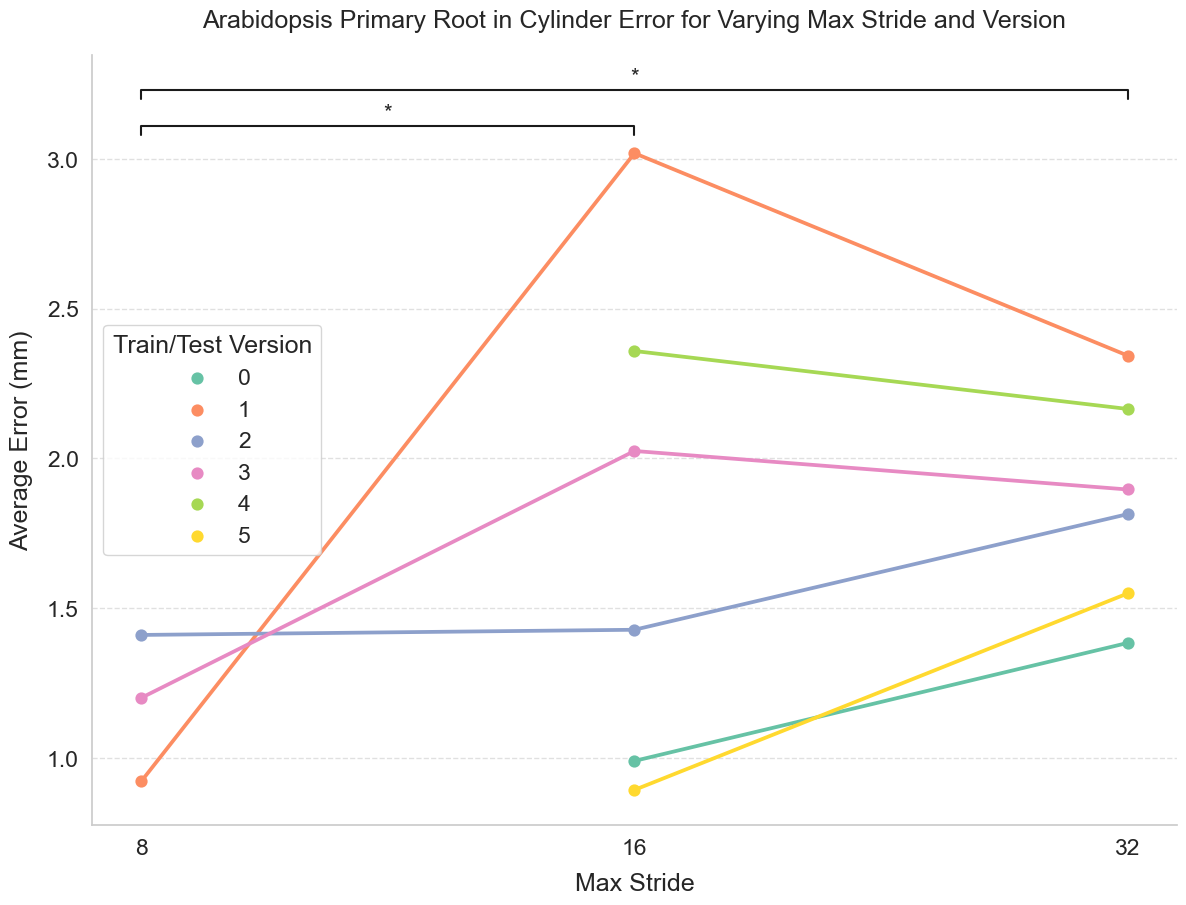

Plot saved to 20250625_cyl_arabidopsis_primary_receptive_field\2025-07-01_09-00-20_max_stride_sweep_eval_version_sig.png


In [29]:
# Determine significant pairwise differences
significant_pairs = []
for a, b in combinations(pivot.columns, 2):
    stat, p = wilcoxon(pivot[a], pivot[b])
    if p < 0.05:
        significant_pairs.append((a, b, p))

# ========== PLOTTING ==========
plt.figure(figsize=(14, 10))

ax = sns.pointplot(
    data=data,
    x="input_scale",
    y="dist_avg",
    hue="config/version",
    palette="Set2",
    markers="o",
    linestyles="-",
    errorbar=None
)

plt.title("Arabidopsis Primary Root in Cylinder Error for Varying Max Stride and Version", pad=20)
plt.xlabel("Max Stride", labelpad=10)
plt.ylabel("Average Error (mm)", labelpad=10)

sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Train/Test Version")

# Annotate significance
y_max = data["dist_avg"].max()
offset = 0.02 * y_max
line_height = 0.01 * y_max

# Get sorted unique x-axis values to map max_stride to positions
x_ticks = sorted(data["input_scale"].unique())
x_tick_to_index = {val: idx for idx, val in enumerate(x_ticks)}

for idx, (a, b, p_val) in enumerate(significant_pairs):
    x1 = x_tick_to_index[a]
    x2 = x_tick_to_index[b]
    y = y_max + offset + idx * (line_height * 4)

    # Draw line
    ax.plot([x1, x1, x2, x2], [y, y+line_height, y+line_height, y], lw=1.5, c='k')
    # Draw p-value or asterisk
    annotation = "*" if p_val < 0.05 else "n.s."
    ax.text((x1 + x2) / 2, y + line_height + offset / 5, annotation, ha='center', va='bottom', fontsize=16)

plot_file_path = Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval_version_sig.png"
plt.savefig(plot_file_path, dpi=600, bbox_inches="tight", transparent=True)
plt.show()
print(f"Plot saved to {plot_file_path}")


In [30]:
# selected_version = "000"
# model_name = f"{MODEL_GROUP}_v{selected_version}"


# visualize_predictions_from_artifacts(model_artifact_name=model_name,
#                                      test_artifact_name=model_name,
#                                      output_dir=Path(EXPERIMENT_NAME) / f"{datetime_str}_{model_name}_test_predictions",
#                                      num_frames=5,
#                                      overwrite=False,
# )


In [31]:
# === Initialize the W&B run ===
add_files_run = wandb.init(
    project=PROJECT_NAME,
    entity=ENTITY_NAME,
    job_type="add_files_to_artifact"
)

# === Create a new artifact ===
new_metrics_artifact = wandb.Artifact(name=ARTIFACT_NAME, type="metrics")
new_metrics_artifact.description = (
    f"Summary plots and metrics from {len(sweep_ids)} sweeps for experiment '{EXPERIMENT_NAME}'."
)
new_metrics_artifact.metadata.update({
    "source_sweep_ids": sweep_ids,
    "experiment_name": EXPERIMENT_NAME,
    "metrics": TARGET_METRICS,
    "generated_at": datetime_str,
})

# === Add plots and CSVs ===
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval.png").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval_version.png").as_posix())
new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval_version_sig.png").as_posix())
new_metrics_artifact.add_file(Path(label_csv_path).as_posix())
new_metrics_artifact.add_file(Path(sweep_csv_path).as_posix())

# === Add run references (optional) ===
api = wandb.Api()
for sweep_id in sweep_ids:
    sweep = api.sweep(f"{ENTITY_NAME}/{PROJECT_NAME}/{sweep_id}")
    for run in sweep.runs:
        if run.state != "finished":
            continue
        new_metrics_artifact.add_reference(run.url)

# === Log and finish ===
add_files_run.log_artifact(new_metrics_artifact)
add_files_run.finish()


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: eberrigan (eberrigan-salk-institute-for-biological-studies). Use `wandb login --relogin` to force relogin


In [32]:
# # === Initialize the W&B run ===
# add_files_run = wandb.init(
#     project=PROJECT_NAME,
#     entity=ENTITY_NAME,
#     job_type="add_files_to_artifact"
# )

# # === Use existing artifact and download its contents ===
# # metrics_artifact = add_files_run.use_artifact(f"{ARTIFACT_NAME}:latest", type="metrics")
# # artifact_dir = Path(metrics_artifact.download())
# # print(f"Artifact downloaded to: {artifact_dir}")

# # === Create a new artifact ===
# new_metrics_artifact = wandb.Artifact(name=ARTIFACT_NAME, type="metrics")

# # === Add plots ===
# new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval.png").as_posix())
# new_metrics_artifact.add_file((Path(EXPERIMENT_NAME) / f"{datetime_str}_max_stride_sweep_eval_version.png").as_posix())

# # === Add associated CSVs ===
# new_metrics_artifact.add_file((Path(label_csv_path)).as_posix())
# new_metrics_artifact.add_file((Path(sweep_csv_path)).as_posix())

# # === Add existing artifact contents ===
# # for file_path in artifact_dir.iterdir():
# #     new_metrics_artifact.add_file(file_path)

# # === Log and finish ===
# add_files_run.log_artifact(new_metrics_artifact)
# add_files_run.finish()